In [1]:
# Si estás en Google Colab o en un entorno donde PennyLane o networkx no están instalados, puedes usar los siguientes comandos para instalarlos:

!pip install pennylane
!pip install networkx

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


# Sesión 13 Laboratorio de Computación Cuántica 2

## Algoritmo QAOA (Quantum Approximate Optimization Algorithm)

En la sesión anterior vimos cómo tomar un problema combinatorio, escribirlo como una función QUBO y después transformarlo a un Hamiltoniano tipo Ising.

La idea central fue:

$$
\text{Problema combinatorio}
\longrightarrow
\text{QUBO}
\longrightarrow
\text{Hamiltoniano de Ising}
\longrightarrow
\text{Hamiltoniano cuántico}
$$

En esta sesión vamos a finalizar la resolución de problemas combinatorios con un algoritmo diseñado para eso, el algoritmo QAOA.

Ya sabemos usar VQE para encontrar aproximadamente el estado base de un Hamiltoniano. Sin embargo, VQE usa un ansatz relativamente general. QAOA también es un algoritmo variacional, pero usa un ansatz diseñado específicamente para problemas de optimización combinatoria.

## Recordatorio: Max-Cut

En Max-Cut tenemos un grafo:

$$
G = (V,E)
$$

donde:

- $V$ es el conjunto de nodos.
- $E$ es el conjunto de aristas.

El objetivo es dividir los nodos en dos grupos, digamos $A$ y $B$, de forma que el mayor número posible de aristas conecte nodos en grupos distintos.

Asignamos una variable binaria a cada nodo:

$$
x_i \in \{0,1\}
$$

donde $x_i = 0$ representa que el nodo está en un grupo y $x_i = 1$ representa que está en el otro.

Para una arista $(i,j)$, la arista cruza el corte si:

$$
x_i \neq x_j
$$

La expresión binaria que detecta esto es:

$$
x_i + x_j - 2x_ix_j.
$$

Por lo tanto, el valor total del corte es:

$$
C(x)=\sum_{(i,j)\in E}(x_i+x_j-2x_ix_j).
$$

Max-Cut busca maximizar esta función.

## De Max-Cut a Hamiltoniano de Ising

En la sesión anterior vimos que podemos cambiar de variables binarias a variables de espín:

$$
z_i \in \{-1,1\}.
$$

Una arista contribuye al corte cuando los espines son distintos. Esto puede escribirse como:

$$
C_{ij} = \frac{1-z_i z_j}{2}.
$$

Entonces:

$$
C(z)=\sum_{(i,j)\in E}\frac{1-z_i z_j}{2}.
$$

Si queremos maximizar el corte, una forma equivalente es minimizar el negativo:

$$
H_C(z)
=
-C(z)
=
-\sum_{(i,j)\in E}\frac{1-z_i z_j}{2}.
$$

Expandiendo:

$$
H_C(z)
=
-\frac{|E|}{2}
+
\frac{1}{2}\sum_{(i,j)\in E}z_i z_j.
$$

La constante $-\frac{|E|}{2}$ no cambia qué configuración minimiza la energía. Por eso, para la optimización podemos usar:

$$
H_C
=
\frac{1}{2}\sum_{(i,j)\in E}Z_iZ_j.
$$

Este será lo que nosotros le llamareos un **Hamiltoniano de costo**

## ¿Que es exactamente el QAOA?

QAOA significa:

$$
\text{Quantum Approximate Optimization Algorithm}
$$

Es un algoritmo cuantico variacional híbrido cuántico-clásico, igual que VQE.

Pero la diferencia importante es la siguiente:

- En **VQE**, elegimos un ansatz más general.
- En **QAOA**, el ansatz se construye alternando dos evoluciones:
  1. Una evolución generada por el Hamiltoniano de costo.
  2. Una evolución generada por un Hamiltoniano mezclador (Ahorita veremos que es eso).

La forma general del estado con el que se trabaja el QAOA es:

$$
|\psi(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle
=
\prod_{\ell=1}^{p}
e^{-i\beta_\ell H_M}
e^{-i\gamma_\ell H_C}
|+\rangle^{\otimes n}.
$$

Aquí:

- $H_C$ es el Hamiltoniano de costo.
- $H_M$ es el Hamiltoniano mezclador.
- $\gamma_\ell$ controla cuánto tiempo evoluciona el sistema bajo el Hamiltoniano de costo.
- $\beta_\ell$ controla cuánto tiempo evoluciona el sistema bajo el Hamiltoniano mezclador.
- $p$ es la profundidad del circuito QAOA.

Nota como iniciamos en el estado $|+\rangle$. Esto no es casualidad, precisamente se busca una superposición uniforme de todas las soluciones binarias posinles. 

Para n qubits

$$
|+\rangle^{\otimes n}
=
\frac{1}{\sqrt{2^n}}
\sum_{x\in\{0,1\}^n}|x\rangle.
$$

## Hamiltoniano mezclador

El Hamiltoniano mezclador estándar es:

$$
H_M = \sum_i X_i.
$$

Este Hamiltoniano usa operadores de Pauli $X$ porque $X$ cambia los estados computacionales:

$$
X|0\rangle = |1\rangle,
\qquad
X|1\rangle = |0\rangle.
$$

Intuitivamente, el mezclador permite que el circuito explore diferentes soluciones.

En QAOA alternamos:

$$
H_C \quad \text{y} \quad H_M.
$$

El Hamiltoniano de costo introduce información del problema.

El mezclador permite moverse por el espacio de soluciones.

La razón por la cual se usan 2 Hamiltonianos es de hecho bastante simple, piensalo de esta forma: El Hamiltoniano de costo permite que nos acerquemos a la solución, mientras que el Hamiltoniano Mezclador permite que nos brinquemos los mínimos locales.

En esta ocasión los parámetros entrenables pasan a se $\gamma$ y $\beta$

In [2]:
import pennylane as qml
from pennylane import numpy as pnp

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from itertools import product
from collections import Counter

Usaremos el mismo grafo de la sesión anterior para que la comparación sea directa:

$$
E=\{(0,1),(1,2),(2,3),(3,0),(0,2)\}.
$$

Este grafo tiene 4 nodos y 5 aristas.

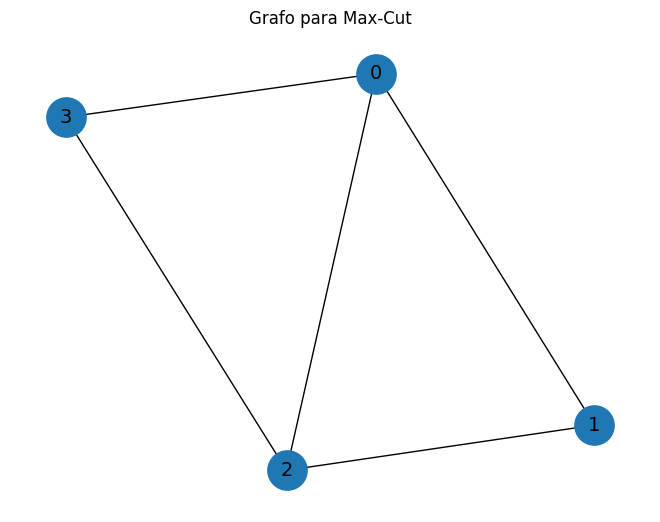

In [3]:
G = nx.Graph()

edges = [
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 0),
    (0, 2)
]

G.add_edges_from(edges)

n_qubits = G.number_of_nodes() # Número de nodos en el grafo

pos = nx.spring_layout(G, seed=42) # Posiciones para una mejor visualización

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=800,
    font_size=14
)

plt.title("Grafo para Max-Cut")
plt.show()

## Construimos el Hamiltoniano de costo

Para Max-Cut vamos a usar:

$$
H_C
=
\frac{1}{2}\sum_{(i,j)\in E}Z_iZ_j.
$$

Recordemos el signo:

- Minimizar este Hamiltoniano equivale a maximizar el corte.
- La constante que quitamos no cambia cuál bitstring es óptimo.
- Si queremos recuperar el valor del corte desde la energía, usamos:

$$
C = \frac{|E|}{2} - E.
$$

donde $E$ es la energía esperada del Hamiltoniano sin constante.

In [4]:
coeffs = []
observables = []

for i, j in G.edges():
    coeffs.append(0.5)
    observables.append(qml.PauliZ(i) @ qml.PauliZ(j))

H_cost = qml.Hamiltonian(coeffs, observables)

H_cost

(
    0.5 * (Z(0) @ Z(1))
  + 0.5 * (Z(0) @ Z(3))
  + 0.5 * (Z(0) @ Z(2))
  + 0.5 * (Z(1) @ Z(2))
  + 0.5 * (Z(2) @ Z(3))
)

## Construimos el Hamiltoniano mezclador

Usaremos el mezclador estándar:

$$
H_M = \sum_i X_i.
$$

En PennyLane lo escribimos como una suma de operadores de Pauli $X$.

In [5]:
mixer_coeffs = []
mixer_observables = []

for i in range(n_qubits):
    mixer_coeffs.append(1.0)
    mixer_observables.append(qml.PauliX(i))

H_mixer = qml.Hamiltonian(mixer_coeffs, mixer_observables)

H_mixer

1.0 * X(0) + 1.0 * X(1) + 1.0 * X(2) + 1.0 * X(3)

## Una capa de QAOA

Una capa de QAOA tiene dos partes:

$$
e^{-i\gamma H_C}
$$

y

$$
e^{-i\beta H_M}.
$$

En PennyLane podemos usar:

```python
qml.qaoa.cost_layer(gamma, H_cost)
qml.qaoa.mixer_layer(beta, H_mixer)
```

Esto aplica las evoluciones correspondientes de forma automática.

In [6]:
def qaoa_layer(gamma, beta):
    qml.qaoa.cost_layer(gamma, H_cost)
    qml.qaoa.mixer_layer(beta, H_mixer)

## Circuito QAOA

La estructura completa será:

1. Preparar $|+\rangle^{\otimes n}$ aplicando Hadamards.
2. Aplicar $p$ capas de QAOA.
3. Medir el valor esperado del Hamiltoniano de costo.

El parámetro $p$ controla la profundidad del ansatz.

- Si $p=1$, usamos una sola capa.
- Si $p=2$, usamos dos capas.
- En general, mayor $p$ puede dar mejores resultados, pero también hace más difícil la optimización.

In [7]:
p = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def qaoa_circuit(params):
    gammas = params[0] # Parámetros para la capa de costo
    betas = params[1] # Parámetros para la capa de mezcla

    for wire in range(n_qubits): # Inicialización en superposición uniforme
        qml.Hadamard(wires=wire)

    for layer in range(p): # Iterar sobre las capas
        qaoa_layer(gammas[layer], betas[layer])

    return qml.expval(H_cost)

## Inicialización de parámetros

Para profundidad $p$, necesitamos:

$$
\boldsymbol{\gamma} = (\gamma_1,\gamma_2,\dots,\gamma_p)
$$

y

$$
\boldsymbol{\beta} = (\beta_1,\beta_2,\dots,\beta_p).
$$

Guardaremos ambos en un arreglo de tamaño:

$$
2\times p.
$$

La primera fila serán los $\gamma$.

La segunda fila serán los $\beta$.

In [8]:
rng = np.random.default_rng(42) # Semilla para reproducibilidad (siempre es buena idea usar una semilla para resultados consistentes)

initial_params = pnp.array(
    [
        rng.uniform(0, np.pi, size=p),        # gammas
        rng.uniform(0, np.pi / 2, size=p)     # betas
    ],
    requires_grad=True # Permitir gradientes para optimización posterior
)

print(initial_params)
print("Energía inicial:", qaoa_circuit(initial_params)) # Evaluar la energía inicial con los parámetros aleatorios

[[2.43145464 1.37877728]
 [1.34868246 1.09542314]]
Energía inicial: -0.13046549033113125


## Optimización clásica

Igual que en VQE, ahora usamos una computadora clásica para ajustar los parámetros.

La función objetivo será:

$$
E(\boldsymbol{\gamma},\boldsymbol{\beta})
=
\langle \psi(\boldsymbol{\gamma},\boldsymbol{\beta})|
H_C
|\psi(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle.
$$

Como nuestro $H_C$ está escrito para minimizar energía, el optimizador intentará hacer esta cantidad lo más pequeña posible.

Después podemos traducir esa energía a valor de corte usando:

$$
C \approx \frac{|E|}{2} - E.
$$

In [9]:
optimizer = qml.AdamOptimizer(stepsize=0.1)

params = initial_params

energy_history = []
cut_history = []

steps = 150

for step in range(steps):
    params, energy = optimizer.step_and_cost(qaoa_circuit, params)

    approximate_cut = G.number_of_edges() / 2 - energy

    energy_history.append(energy)
    cut_history.append(approximate_cut)

    if step % 10 == 0:
        print(
            f"Iteración {step:3d} | Energía = {energy:.6f} | Corte esperado ≈ {approximate_cut:.6f}"
        )

print("\nEnergía final:", energy_history[-1])
print("Corte esperado final:", cut_history[-1])
print("\nParámetros óptimos:")
print(params)

Iteración   0 | Energía = -0.130465 | Corte esperado ≈ 2.630465
Iteración  10 | Energía = -0.828940 | Corte esperado ≈ 3.328940
Iteración  20 | Energía = -0.858246 | Corte esperado ≈ 3.358246
Iteración  30 | Energía = -0.859241 | Corte esperado ≈ 3.359241
Iteración  40 | Energía = -0.878084 | Corte esperado ≈ 3.378084
Iteración  50 | Energía = -0.885679 | Corte esperado ≈ 3.385679
Iteración  60 | Energía = -0.886029 | Corte esperado ≈ 3.386029
Iteración  70 | Energía = -0.886314 | Corte esperado ≈ 3.386314
Iteración  80 | Energía = -0.886756 | Corte esperado ≈ 3.386756
Iteración  90 | Energía = -0.886856 | Corte esperado ≈ 3.386856
Iteración 100 | Energía = -0.886842 | Corte esperado ≈ 3.386842
Iteración 110 | Energía = -0.886864 | Corte esperado ≈ 3.386864
Iteración 120 | Energía = -0.886865 | Corte esperado ≈ 3.386865
Iteración 130 | Energía = -0.886866 | Corte esperado ≈ 3.386866
Iteración 140 | Energía = -0.886867 | Corte esperado ≈ 3.386867

Energía final: -0.8868667934122186
Cort

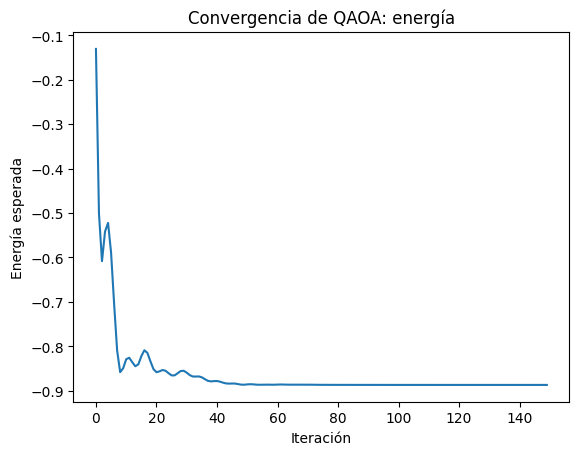

In [10]:
plt.plot(energy_history)
plt.xlabel("Iteración")
plt.ylabel("Energía esperada")
plt.title("Convergencia de QAOA: energía")
plt.show()